In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

In [162]:
df = pd.read_csv("Ho Chi Minh.csv")
print(df)

            name             datetime  temp  feelslike   dew  humidity  \
0    Ho Chi Minh  2026-06-24T00:00:00  84.1       90.7  73.3     70.10   
1    Ho Chi Minh  2026-06-24T01:00:00  82.3       89.3  75.1     78.91   
2    Ho Chi Minh  2026-06-24T02:00:00  82.3       92.1  78.7     88.91   
3    Ho Chi Minh  2026-06-24T03:00:00  82.3       92.1  78.7     88.91   
4    Ho Chi Minh  2026-06-24T04:00:00  82.3       93.8  80.5     94.31   
..           ...                  ...   ...        ...   ...       ...   
355  Ho Chi Minh  2026-07-08T19:00:00  76.7       76.7  72.6     87.07   
356  Ho Chi Minh  2026-07-08T20:00:00  76.6       76.6  72.6     87.59   
357  Ho Chi Minh  2026-07-08T21:00:00  76.4       76.4  72.6     88.12   
358  Ho Chi Minh  2026-07-08T22:00:00  76.2       76.2  72.6     88.64   
359  Ho Chi Minh  2026-07-08T23:00:00  75.8       75.8  72.5     89.53   

     precip  precipprob preciptype  snow  ...  sealevelpressure  cloudcover  \
0     0.000           0        N

**Split datetime**
- Using ```str.split(a)``` to split Series of string
- Insert to dataframe at expected index

In [163]:
datetime = df["datetime"]
df[["date", "time"]] = df["datetime"].str.split("T", expand=True)
print(df.head())

          name             datetime  temp  feelslike   dew  humidity  precip  \
0  Ho Chi Minh  2026-06-24T00:00:00  84.1       90.7  73.3     70.10     0.0   
1  Ho Chi Minh  2026-06-24T01:00:00  82.3       89.3  75.1     78.91     0.0   
2  Ho Chi Minh  2026-06-24T02:00:00  82.3       92.1  78.7     88.91     0.0   
3  Ho Chi Minh  2026-06-24T03:00:00  82.3       92.1  78.7     88.91     0.0   
4  Ho Chi Minh  2026-06-24T04:00:00  82.3       93.8  80.5     94.31     0.0   

   precipprob preciptype  snow  ...  visibility  solarradiation  solarenergy  \
0           0        NaN     0  ...         6.2             0.0          0.0   
1           0        NaN     0  ...         6.2             0.0          0.0   
2           0        NaN     0  ...         6.2             0.0          0.0   
3           0        NaN     0  ...         6.2             0.0          0.0   
4           0        NaN     0  ...         6.2             0.0          0.0   

   uvindex  severerisk        conditio

In [164]:
df[["year", "month", "day"]] = df["date"].str.split("-", expand=True)

**Average C Temperature in each day**
Use groupby and mean

In [165]:
temperature_F = df["temp"]
temperature_C = (temperature_F - 32) * 5 / 9
df.insert(5, "temp_c", temperature_C)
temp_f = df["temp"]
df.insert(4, "temp_f", temp_f)

In [166]:
df_june = df[df["month"]=='06']
df_july = df[df["month"]=='07']

average_temp_june = df_june.groupby("date")["temp_c"].mean().to_numpy()
average_temp_july = df_july.groupby("date")["temp_c"].mean().to_numpy()

june = df_june.groupby("date")["day"].first().to_numpy()
july = df_july.groupby("date")["day"].first().to_numpy()

print(july)

['01' '02' '03' '04' '05' '06' '07' '08']


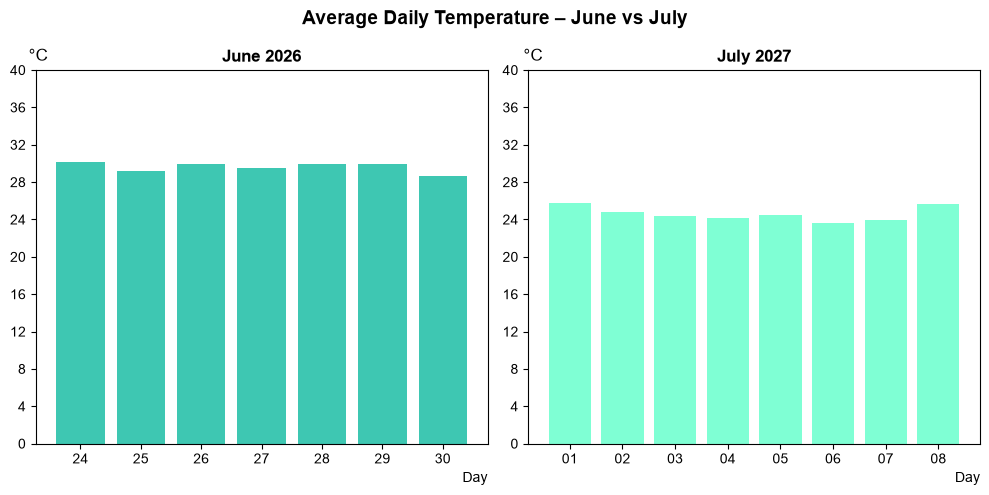

In [201]:
figures, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].bar(june, average_temp_june, color="#3ec7b2")
axes[1].bar(july, average_temp_july, color="#7fffd4")
axes[0].set_yticks(np.linspace(0, 40, 11))
axes[1].set_yticks(np.linspace(0, 40, 11))
axes[0].set_xlabel("Day", loc="right")
axes[0].text(-0.7, 41, "°C", fontsize=12, ha="center")
axes[1].set_xlabel("Day", loc="right")
axes[1].text(-0.7, 41, "°C", fontsize=12, ha="center")

axes[0].set_title("June 2026", fontweight='bold')
axes[1].set_title("July 2027", fontweight='bold')


figures.suptitle("Average Daily Temperature – June vs July", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

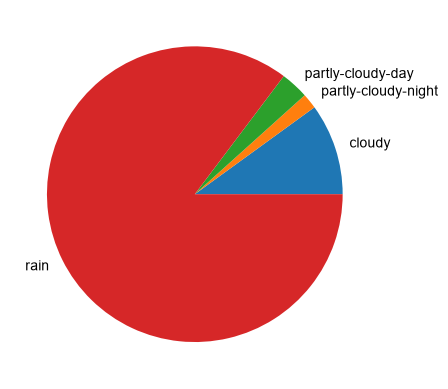

In [ ]:
icons = df["icon"].unique().to_numpy()
icons_count = df["icon"].value_counts(sort=False).to_numpy()

plt.pie(icons_count, labels=icons)

plt.show()